# Diabetes Patient Outcomes Analysis

## Predicting Hospital Readmission Risk Using Patient and Clinical Data

### Objective
This project analyses diabetic patient hospital records to identify factors associated with hospital readmission and develop a predictive model for high-risk patients.

### Dataset
Diabetes 130-US hospitals dataset (1999-2008)

### Problem Type
Binary Classification

### Target Variable
Readmission status

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jimschacko/10-years-diabetes-dataset/diabetes.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/jimschacko/10-years-diabetes-dataset/diabetes.csv')

In [3]:
df.shape


(101766, 51)

In [4]:
df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   id                        101766 non-null  int64 
 1   encounter_id              101766 non-null  int64 
 2   patient_nbr               101766 non-null  int64 
 3   race                      101766 non-null  object
 4   gender                    101766 non-null  object
 5   age                       101766 non-null  object
 6   weight                    101766 non-null  object
 7   admission_type_id         101766 non-null  int64 
 8   discharge_disposition_id  101766 non-null  int64 
 9   admission_source_id       101766 non-null  int64 
 10  time_in_hospital          101766 non-null  int64 
 11  payer_code                101766 non-null  object
 12  medical_specialty         101766 non-null  object
 13  num_lab_procedures        101766 non-null  int64 
 14  num_

## Missing Value Analysis

Before cleaning the dataset, it is important to understand the quality and completeness of the available data.

Healthcare datasets often contain missing information because certain tests, measurements, or patient details may not be collected during every hospital encounter.

This analysis will identify:
- Which variables contain missing values
- The amount of missing information
- Potential data quality issues

The findings will guide the data cleaning strategy later in the project.

In [6]:
# Calculate missing values for each column

missing_values = df.isnull().sum()

# Display only columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

max_glu_serum    96420
A1Cresult        84748
dtype: int64

## Missing Value Findings

The missing value analysis identified two variables containing missing values:

| Variable | Missing Records |
|----------|----------------:|
| max_glu_serum | 96,420 |
| A1Cresult | 84,748 |

### Observations

The dataset contains a significant amount of missing information in laboratory test variables.

- `max_glu_serum` is missing for the majority of patient encounters.
- `A1Cresult` also contains a high level of missing data.

In healthcare datasets, missing values may have a clinical meaning. A missing test result does not always indicate poor data quality; it may mean that the test was not required, requested, or recorded during that hospital encounter.

These variables will be reviewed during the data cleaning stage to decide whether they should be:
- Removed due to excessive missingness
- Converted into meaningful indicators
- Retained with appropriate handling of missing values

At this stage, no changes are made to the dataset.

## Duplicate Record Analysis

Before beginning data cleaning and analysis, it is important to check whether the dataset contains duplicate records.

Duplicate rows can affect:
- Patient counts
- Statistical analysis
- Model training
- Prediction accuracy

This analysis identifies whether exact duplicate hospital encounters exist in the dataset.

If duplicates are found, they will be reviewed before deciding whether they should be removed.

In [7]:
# Check for duplicate rows in the dataset

duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

## Duplicate Record Findings

The duplicate record analysis found:

- Duplicate rows identified: 0

This indicates that each hospital encounter record is unique within the dataset.

No duplicate removal is required at this stage.

The dataset can proceed to further quality checks and exploratory analysis.

## Readmission Outcome Analysis

The target variable for this project is `readmitted`.

This variable represents whether a diabetic patient returned to hospital after discharge.

The original categories are:

- `NO` → Patient was not readmitted
- `>30` → Patient was readmitted after 30 days
- `<30` → Patient was readmitted within 30 days

Understanding the distribution of these outcomes is important because the machine learning model will later focus on predicting early readmission risk.

In [8]:
# Count the number of records in each readmission category

df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

## Readmission Outcome Findings

The target variable (`readmitted`) contains three outcome categories representing patient readmission status after discharge.

| Readmission Status | Number of Records |
|-------------------|------------------:|
| NO | 54,864 |
| >30 | 35,545 |
| <30 | 11,357 |

### Observations

- Approximately half of the hospital encounters did not result in patient readmission.
- A substantial number of patients were readmitted after 30 days.
- Readmissions within 30 days represent the smallest group in the dataset.

From a healthcare perspective, readmission within 30 days is often considered an important quality indicator because it may reflect complications, ineffective discharge planning, or the need for additional follow-up care.

During the machine learning phase, the target variable will be transformed into a binary classification problem, where early readmission (`<30`) represents the positive class.

## Readmission Distribution

Visualising the target variable provides a quick overview of the distribution of patient outcomes.

Understanding class distribution is important before building predictive models because an imbalanced dataset may influence model performance and evaluation metrics.

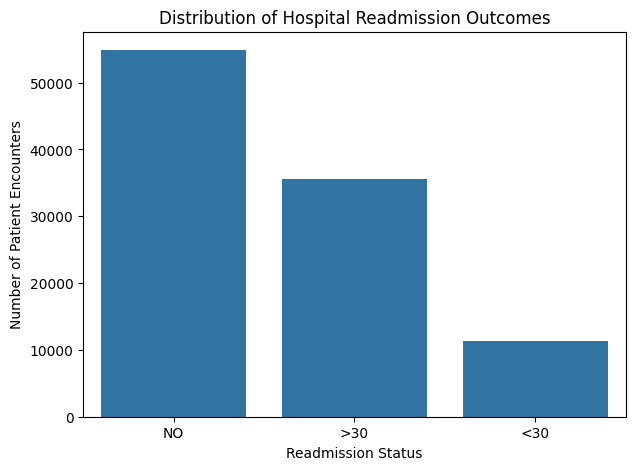

In [9]:
# Display the distribution of readmission outcomes

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='readmitted',
    order=df['readmitted'].value_counts().index
)

plt.title('Distribution of Hospital Readmission Outcomes')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patient Encounters')

plt.show()

## Dataset Quality Assessment

In addition to standard missing values (`NaN`), healthcare datasets often contain placeholder values that represent missing or unavailable information.

In this dataset, some variables use the character `"?"` instead of a true missing value.

These placeholder values are not recognised by pandas as missing data and therefore require additional investigation before the data cleaning process begins.

The objective of this analysis is to:

- Identify variables containing placeholder values.
- Measure the extent of hidden missing data.
- Determine which variables may require cleaning or transformation.

In [10]:
# Count the number of '?' values in each column

question_mark_counts = (df == '?').sum()

# Display only columns containing '?' values
question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

## Dataset Quality Findings

The analysis identified several variables containing the placeholder value `"?"`, which represents missing or unavailable information.

| Variable | Placeholder (`?`) Count |
|----------|------------------------:|
| weight | 98,569 |
| medical_specialty | 49,949 |
| payer_code | 40,256 |
| race | 2,273 |
| diag_3 | 1,423 |
| diag_2 | 358 |
| diag_1 | 21 |

### Key Findings

Several important variables contain hidden missing values that were not detected during the initial missing value analysis because they are stored as the character `"?"` rather than as standard `NaN` values.

The `weight` variable contains placeholder values for the majority of patient encounters, while `medical_specialty` and `payer_code` also have a substantial proportion of missing information.

The diagnosis variables (`diag_1`, `diag_2`, and `diag_3`) contain relatively few placeholder values and may still provide valuable clinical information after appropriate cleaning.

### Conclusion

Before any exploratory analysis or predictive modelling, these placeholder values must be converted to standard missing values (`NaN`) to ensure they are handled correctly during the data cleaning process.

No data has been modified at this stage; this analysis was conducted solely to assess data quality.

# Data Cleaning

Before performing exploratory data analysis and predictive modelling, the dataset must be cleaned to improve its quality and consistency.

The data quality assessment identified that several variables use the character `"?"` to represent missing information. Since pandas does not recognise this character as a missing value, it must first be converted to the standard `NaN` format.

This ensures that missing data can be correctly identified, analysed, and handled in the subsequent stages of the project.

The cleaning process will be carried out gradually, with each decision documented and justified.

## Converting Placeholder Values to Missing Values

Several variables in the dataset use the placeholder value `"?"` instead of a standard missing value (`NaN`).

To ensure consistent data handling throughout the project, all occurrences of `"?"` will be replaced with `NaN`.

This does not remove any data; it simply standardises how missing values are represented.

In [11]:
# Replace all '?' values with standard missing values (NaN)

df = df.replace('?', np.nan)

# Display the first few rows to confirm the replacement
df.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [12]:
df.isnull().sum().sort_values(ascending=False).head(10)

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
id                       0
dtype: int64

## Data Cleaning Findings

After converting all placeholder values (`"?"`) to standard missing values (`NaN`), the dataset now provides an accurate representation of missing information.

### Updated Missing Value Summary

| Variable | Missing Values |
|----------|---------------:|
| weight | 98,569 |
| max_glu_serum | 96,420 |
| A1Cresult | 84,748 |
| medical_specialty | 49,949 |
| payer_code | 40,256 |
| race | 2,273 |
| diag_3 | 1,423 |
| diag_2 | 358 |
| diag_1 | 21 |

### Key Findings

The updated results confirm that several variables contained hidden missing values stored as placeholder characters rather than true missing values.

The `weight` variable contains missing values for the majority of patient encounters, while `max_glu_serum` and `A1Cresult` also have very high levels of missing information.

The diagnosis variables contain relatively few missing values and are likely to remain valuable for further analysis.

Standardising missing values ensures that future data cleaning, exploratory analysis, and predictive modelling are based on accurate and consistent information.

## Missing Data Percentage Analysis

The number of missing values alone does not provide sufficient context for making data cleaning decisions.

Calculating the percentage of missing values for each variable allows us to assess the severity of missingness relative to the size of the dataset.

This analysis will help determine whether variables should be retained, transformed, or removed during the data cleaning process.

In [13]:
# Calculate the percentage of missing values for each column

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

# Display only columns with missing values
missing_percentage[missing_percentage > 0].round(2)

weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

## Missing Data Percentage Findings

The percentage of missing values was calculated for each variable to support evidence-based data cleaning decisions.

| Variable | Missing (%) |
|----------|------------:|
| weight | 96.86% |
| max_glu_serum | 94.75% |
| A1Cresult | 83.28% |
| medical_specialty | 49.08% |
| payer_code | 39.56% |
| race | 2.23% |
| diag_3 | 1.40% |
| diag_2 | 0.35% |
| diag_1 | 0.02% |

### Key Findings

The dataset contains varying levels of missing information across several variables.

- `weight`, `max_glu_serum`, and `A1Cresult` have extremely high levels of missing data, with over 80% of records unavailable.
- `medical_specialty` and `payer_code` contain moderate levels of missing data but may still provide useful information.
- `race`, `diag_1`, `diag_2`, and `diag_3` have relatively low levels of missing data and are likely to remain valuable for analysis.

### Next Steps

Rather than applying a single rule to all variables, each feature will be assessed individually based on:

- The proportion of missing data
- Clinical relevance
- Potential value for exploratory analysis and predictive modelling

This approach ensures that data cleaning decisions are transparent, justified, and aligned with good analytical practice.

## Data Cleaning Decision Framework

To ensure a transparent and reproducible data cleaning process, each variable containing missing values will be assessed using a structured decision framework.

The framework considers three key factors:

- **Missing Data Percentage** – How much information is unavailable?
- **Business Importance** – How valuable is the variable from a clinical and analytical perspective?
- **Cleaning Decision** – Should the variable be retained, transformed, or removed?

Using a structured framework ensures that data cleaning decisions are evidence-based and can be clearly justified throughout the project.

In [14]:
# Create the initial data cleaning decision table

cleaning_decision = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# Keep only variables with missing values
cleaning_decision = cleaning_decision[
    cleaning_decision['Missing Values'] > 0
].copy()

# Create empty columns for later assessment
cleaning_decision['Business Importance'] = ""
cleaning_decision['Decision'] = ""

cleaning_decision

,Missing Values,Missing Percentage (%),Business Importance,Decision
race,2273,2.23,,
weight,98569,96.86,,
payer_code,40256,39.56,,
medical_specialty,49949,49.08,,
diag_1,21,0.02,,
diag_2,358,0.35,,
diag_3,1423,1.40,,
max_glu_serum,96420,94.75,,
A1Cresult,84748,83.28,,


## Assessing Business Importance and Cleaning Decisions

Each variable with missing data has been reviewed based on its relevance to the project objectives.

The objective of this project is to identify factors associated with hospital readmission. Therefore, variables that provide important demographic or clinical information are retained where possible, while variables with extremely high levels of missing data and limited analytical value are considered for removal.

The following decisions represent the proposed data cleaning strategy and will be implemented in the next section.

In [15]:
# Populate the decision framework

cleaning_decision.loc['weight', 'Business Importance'] = 'Low'
cleaning_decision.loc['weight', 'Decision'] = 'Remove'

cleaning_decision.loc['max_glu_serum', 'Business Importance'] = 'Medium'
cleaning_decision.loc['max_glu_serum', 'Decision'] = 'Remove'

cleaning_decision.loc['A1Cresult', 'Business Importance'] = 'Medium'
cleaning_decision.loc['A1Cresult', 'Decision'] = 'Remove'

cleaning_decision.loc['medical_specialty', 'Business Importance'] = 'Medium'
cleaning_decision.loc['medical_specialty', 'Decision'] = 'Keep (Missing = Unknown)'

cleaning_decision.loc['payer_code', 'Business Importance'] = 'Low'
cleaning_decision.loc['payer_code', 'Decision'] = 'Remove'

cleaning_decision.loc['race', 'Business Importance'] = 'High'
cleaning_decision.loc['race', 'Decision'] = 'Keep (Impute Missing)'

cleaning_decision.loc['diag_1', 'Business Importance'] = 'High'
cleaning_decision.loc['diag_1', 'Decision'] = 'Keep (Impute Missing)'

cleaning_decision.loc['diag_2', 'Business Importance'] = 'High'
cleaning_decision.loc['diag_2', 'Decision'] = 'Keep (Impute Missing)'

cleaning_decision.loc['diag_3', 'Business Importance'] = 'High'
cleaning_decision.loc['diag_3', 'Decision'] = 'Keep (Impute Missing)'

cleaning_decision

,Missing Values,Missing Percentage (%),Business Importance,Decision
race,2273,2.23,High,Keep (Impute Missing)
weight,98569,96.86,Low,Remove
payer_code,40256,39.56,Low,Remove
medical_specialty,49949,49.08,Medium,Keep (Missing = Unknown)
diag_1,21,0.02,High,Keep (Impute Missing)
diag_2,358,0.35,High,Keep (Impute Missing)
diag_3,1423,1.40,High,Keep (Impute Missing)
max_glu_serum,96420,94.75,Medium,Remove
A1Cresult,84748,83.28,Medium,Remove


## Decision Summary

The data cleaning assessment identified three categories of variables:

### Variables to Remove

The following variables contain a very high proportion of missing values and are unlikely to provide reliable analytical value:

- `weight`
- `max_glu_serum`
- `A1Cresult`
- `payer_code`

### Variables to Retain

The following variables contain valuable demographic or clinical information and will be retained:

- `medical_specialty`
- `race`
- `diag_1`
- `diag_2`
- `diag_3`

For these variables, missing values will be handled during the cleaning process rather than removing the entire feature.

This approach balances data quality with the preservation of clinically relevant information, ensuring that potentially valuable predictors are not discarded unnecessarily.

## Data Cleaning Decisions

Based on the missing value analysis and business relevance assessment, the following cleaning decisions will be applied.

Variables with extremely high missing values will be removed because they provide limited analytical value.

In [16]:
# Remove variables with extremely high missing values
# and limited analytical value

columns_to_remove = [
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'payer_code'
]

df = df.drop(columns=columns_to_remove)

# Check remaining columns
df.shape

(101766, 47)

## Feature Removal Findings

Four variables were removed from the dataset:

| Variable | Reason for Removal |
|----------|-------------------|
| weight | Missing in approximately 97% of records, making reliable analysis difficult |
| max_glu_serum | Missing in approximately 95% of records |
| A1Cresult | Missing in approximately 83% of records |
| payer_code | High missingness with limited relevance to the readmission prediction objective |

### Impact of Removal

- The number of patient encounters remains unchanged.
- The dataset now contains fewer unreliable features.
- The remaining variables have stronger potential analytical value.

Removing these variables reduces noise and improves the quality of the dataset before exploratory analysis and modelling.

Further cleaning will focus on handling remaining missing values in clinically relevant variables.

## Handling Remaining Categorical Missing Values

After removing variables with excessive missing data, several clinically relevant categorical variables still contain missing values.

The remaining variables are:

- `medical_specialty`
- `race`
- `diag_1`
- `diag_2`
- `diag_3`

Instead of removing these records, missing values will be replaced with the category `"Unknown"`.

This approach:

- Preserves patient records
- Maintains the information that the value was unavailable
- Allows categorical variables to be used during exploratory analysis and machine learning

Creating an explicit missing category is a common approach when working with real-world healthcare datasets.

In [17]:
# Replace missing categorical values with "Unknown"

categorical_missing_columns = [
    'medical_specialty',
    'race',
    'diag_1',
    'diag_2',
    'diag_3'
]

for col in categorical_missing_columns:
    df[col] = df[col].fillna('Unknown')

# Confirm missing values have been handled
df[categorical_missing_columns].isnull().sum()

medical_specialty    0
race                 0
diag_1               0
diag_2               0
diag_3               0
dtype: int64

## Categorical Missing Value Handling Findings

The remaining categorical variables with missing information were handled by replacing missing values with the category `"Unknown"`.

| Variable | Missing Values After Cleaning |
|----------|------------------------------:|
| medical_specialty | 0 |
| race | 0 |
| diag_1 | 0 |
| diag_2 | 0 |
| diag_3 | 0 |

### Key Findings

All remaining categorical variables now contain complete information.

Using an `"Unknown"` category allows the analysis to:

- Preserve all patient encounters
- Avoid unnecessary data loss
- Retain potentially useful information about missing clinical records

This approach is appropriate for healthcare datasets where missing information may reflect clinical decisions, unavailable records, or differences in data collection processes.

## Final Missing Value Validation

After completing the initial cleaning process, a final missing value check is performed.

This validation confirms whether any missing values remain in the dataset and ensures that the data is ready for exploratory analysis.

The objective is to verify that all identified missing value issues have been addressed appropriately.

In [18]:
# Check remaining missing values in the dataset

remaining_missing = df.isnull().sum()

remaining_missing[remaining_missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

## Final Missing Value Validation Findings

The final missing value audit confirms that no missing values remain in the cleaned dataset.

### Result

- Remaining variables with missing values: 0

### Data Cleaning Completed

The following data quality issues have been successfully addressed:

✅ Placeholder values (`?`) converted to standard missing values  
✅ High-missingness variables reviewed and removed where appropriate  
✅ Clinically relevant categorical variables retained  
✅ Missing categorical values replaced with `"Unknown"`  
✅ Final dataset contains complete records for analysis  

The cleaned dataset is now prepared for exploratory data analysis (EDA).

The next stage will focus on understanding patient characteristics, hospital utilisation patterns, treatment factors, and their relationship with hospital readmission outcomes.

## Exploratory Data Analysis (EDA)
Patient Demographic Analysis
Purpose

Before building any predictive model, we need to understand the patient population represented in the dataset.

Demographic characteristics can influence:

Healthcare utilisation
Disease progression
Access to care
Treatment patterns
Hospital readmission risk

This section will analyse:

Age distribution
Gender distribution
Race distribution

The key questions are:

Which patient groups are most represented in the dataset?
Are there demographic differences among patients?
Do demographic characteristics appear related to readmission outcomes?

## Patient Age Distribution

Understanding the age profile of diabetic patients is important because diabetes complications and hospital utilisation often increase with age.

This analysis examines how patients are distributed across different age groups and identifies whether the dataset is primarily representing younger or older diabetic patients.


In [19]:
# Age distribution

df['age'].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

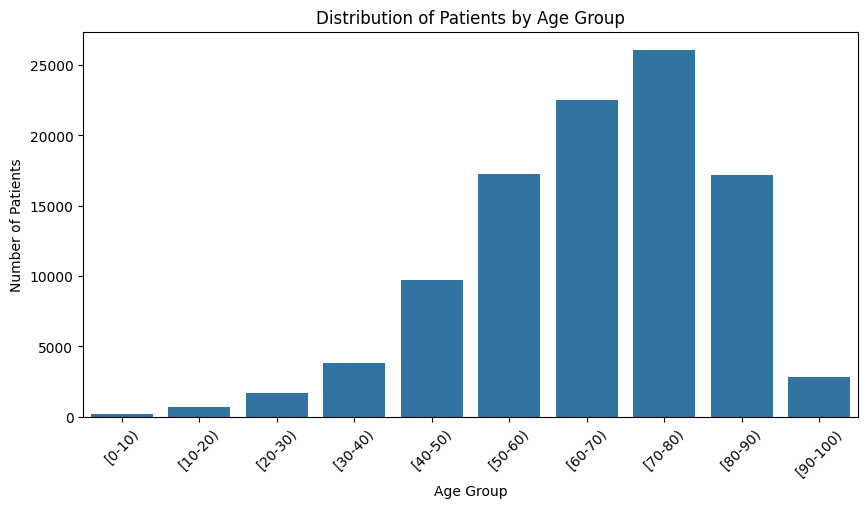

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='age',
    order=df['age'].value_counts().sort_index().index
)

plt.title('Distribution of Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

## Findings — Patient Age Distribution

The dataset contains patients across all age groups, but the majority of hospital encounters are concentrated among older adults.

The largest patient groups are:

- 70–80 years
- 60–70 years
- 80–90 years

This suggests that hospital utilisation within this dataset is strongly represented by older diabetic patients, which is expected because diabetes complications and related health conditions generally increase with age.

Younger age groups represent a much smaller proportion of hospital encounters.

From a modelling perspective, age may be an important predictor because older patients may have higher clinical complexity and greater risk of hospital readmission.

## Patient Gender Distribution

Understanding the gender composition of the patient population helps identify whether hospital encounters are evenly distributed between male and female patients.

This analysis also provides an initial view of whether gender may influence healthcare utilisation patterns or readmission outcomes.

Key questions:

- Are male and female patients represented equally?
- Does readmission behaviour differ between genders?

In [21]:
# Gender distibution

df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

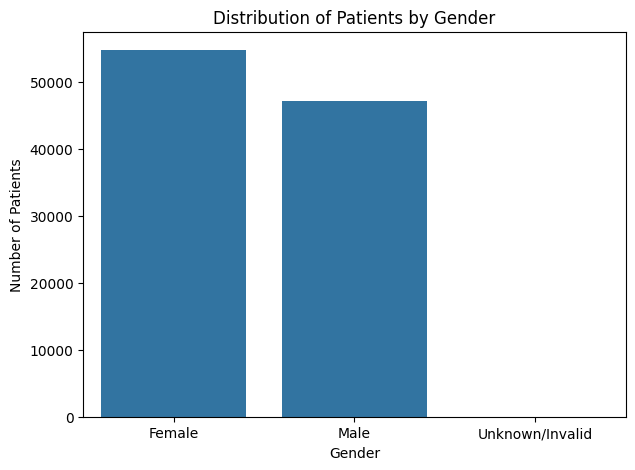

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='gender',
    order=df['gender'].value_counts().index
)

plt.title('Distribution of Patients by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

## Findings — Patient Gender Distribution

The patient population is relatively balanced across genders, with female patients representing a slightly higher proportion of hospital encounters compared with male patients.

Female patients account for approximately 54% of records, while male patients account for approximately 46%.

The small difference suggests that gender alone is unlikely to explain major differences in hospital utilisation within this dataset. However, gender will still be evaluated later against the readmission outcome to determine whether any relationship exists.

The three records classified as "Unknown/Invalid" represent an insignificant proportion of the dataset and are unlikely to affect analysis results.

In [23]:
# Readmission districution as per gender

pd.crosstab(
    df['gender'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
gender,,,
Female,11.245156,35.676683,53.078160
Male,11.061524,34.060142,54.878334
Unknown/Invalid,0.000000,0.000000,100.000000


## Findings — Gender and Readmission Relationship

The analysis shows that readmission patterns are broadly similar between male and female patients.

Female patients have a slightly higher proportion of both early readmissions and readmissions after 30 days, while male patients have a slightly higher proportion of encounters without readmission.

However, the differences between genders are relatively small, suggesting that gender alone is unlikely to be a strong predictor of hospital readmission risk.

During the machine learning phase, gender will be evaluated alongside other clinical and patient-level variables to determine its overall predictive contribution.

In [24]:
# Race Distribution

df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

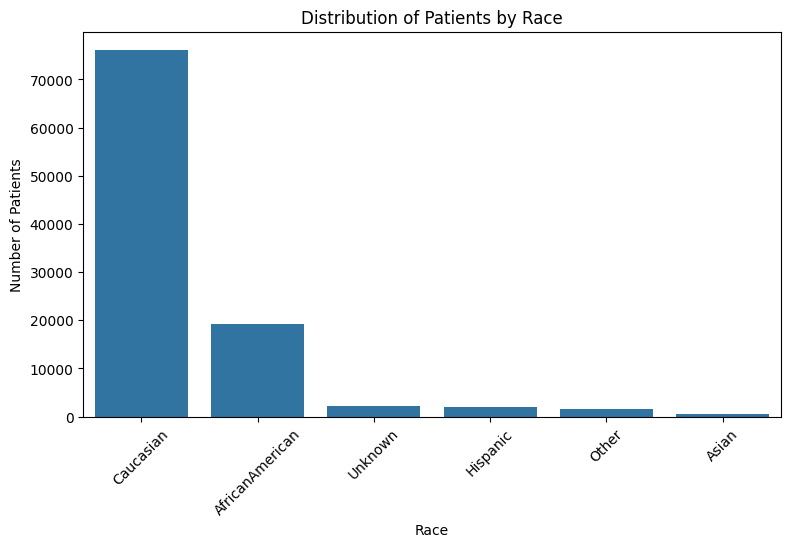

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='race',
    order=df['race'].value_counts().index
)

plt.title('Distribution of Patients by Race')
plt.xlabel('Race')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)

plt.show()

## Findings — Patient Race Distribution

The dataset is heavily concentrated among Caucasian patients, who represent the majority of hospital encounters, followed by AfricanAmerican patients.

Other demographic groups have substantially fewer records, which may limit the ability to identify reliable differences in readmission behaviour for these populations.

The presence of an Unknown category represents previously missing race information that was retained during data cleaning to avoid removing patient records.

Race will be analysed further against readmission outcomes to determine whether any meaningful association exists.

In [26]:
# This analysis examines the relationship between race and hospital readmission outcomes.
# The percentages help identify whether readmission patterns differ across demographic groups.

pd.crosstab(
    df['race'],
    df['readmitted'],
    normalize='index'
) * 100


readmitted,<30,>30,NO
race,,,
AfricanAmerican,11.218116,34.534097,54.247788
Asian,10.140406,25.117005,64.742590
Caucasian,11.290556,35.643044,53.066400
Hispanic,10.407462,31.516937,58.075601
Other,9.628154,29.614874,60.756972
Unknown,8.271007,23.669160,68.059833


## Findings — Race and Readmission Relationship

The analysis shows that readmission patterns vary slightly between racial groups, but the differences are relatively modest.

Caucasian and AfricanAmerican patients show the highest proportions of readmission after 30 days, while Asian and Unknown categories show lower readmission percentages.

However, these differences should be interpreted with caution because demographic groups have unequal representation within the dataset.

Race alone is unlikely to be a strong predictor of hospital readmission risk. Instead, readmission outcomes are likely influenced by a combination of demographic characteristics, clinical conditions, treatment complexity, and healthcare utilisation factors.

Race will therefore be evaluated alongside other clinical variables during feature engineering and machine learning modelling.

In [27]:
# This analysis examines the distribution of the number of diagnoses recorded per patient encounter.
# Higher diagnosis counts may indicate greater clinical complexity and potentially higher readmission risk.

df['number_diagnoses'].describe()

count    101766.000000
mean          7.422607
std           1.933600
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64

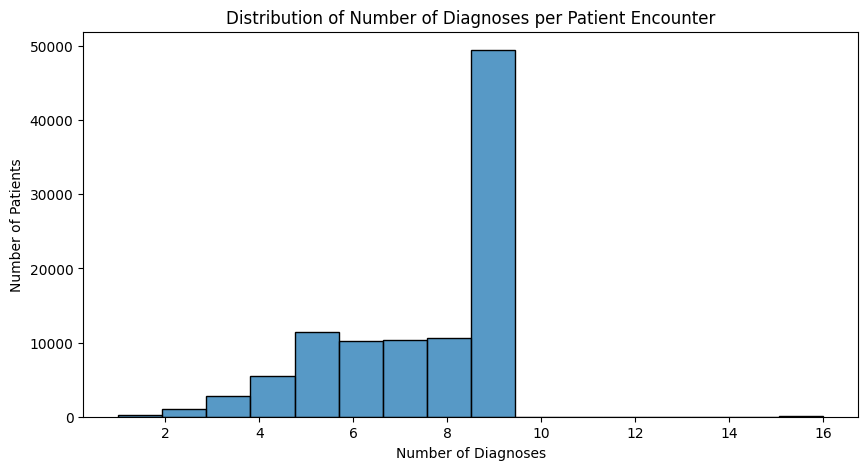

In [28]:
# This visualization shows the distribution of diagnosis counts across patient encounters.
# The chart helps identify whether most patients have low or high clinical complexity.

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='number_diagnoses',
    bins=16
)

plt.title('Distribution of Number of Diagnoses per Patient Encounter')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Number of Patients')

plt.show()

## Findings — Diagnosis Complexity Distribution

The majority of patient encounters contain multiple recorded diagnoses, with an average of approximately 7 diagnoses per encounter.

The distribution indicates that this dataset represents a medically complex diabetic patient population rather than isolated diabetes cases.

A higher number of diagnoses may indicate increased disease burden and healthcare complexity, which could contribute to higher hospital readmission risk.

The relationship between diagnosis complexity and readmission outcomes will be explored further during the clinical risk factor analysis.

In [29]:
# This analysis compares readmission outcomes across different levels of diagnosis complexity.
# It helps determine whether diagnosis burden is associated with increased readmission risk.

df.groupby('readmitted')['number_diagnoses'].mean()

readmitted
<30    7.692789
>30    7.646898
NO     7.221366
Name: number_diagnoses, dtype: float64

## Findings — Diagnosis Complexity and Readmission

The analysis shows that patients who experienced readmission had a slightly higher average number of diagnoses compared with patients who were not readmitted.

Patients readmitted within 30 days had an average of approximately 7.69 diagnoses, compared with 7.22 diagnoses among patients with no readmission.

This suggests that greater clinical complexity may be associated with increased readmission risk. However, the difference is relatively small, indicating that diagnosis count alone is unlikely to explain readmission outcomes.

Diagnosis complexity will therefore be considered alongside other clinical and healthcare utilisation factors during feature engineering and predictive modelling.

## Medication Usage Analysis

### Number of Medications Distribution

In [30]:
# Display the distribution of number of medications prescribed
# This helps understand medication burden across diabetic patients

df["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

## Findings — Number of Medications Distribution

The analysis shows that diabetic patients in the dataset have a relatively high medication burden.

Patients were prescribed an average of approximately 16 medications, with half of the patients receiving between 10 and 20 medications. The median number of medications was 15, indicating that most patients require multiple medications as part of their diabetes management.

A small number of patients had substantially higher medication counts, with the maximum reaching 81 medications. These cases may represent patients with greater clinical complexity or multiple comorbid conditions.

Overall, medication usage provides an indication of patient complexity and will be evaluated alongside other clinical and healthcare utilisation factors to determine its relationship with hospital readmission risk.

### Medication Usage and Readmission Relationship

In [31]:
# Compare average medication usage across readmission groups
# This helps identify whether medication burden is associated with readmission risk

df.groupby("readmitted")["num_medications"].mean()

readmitted
<30    16.903143
>30    16.282768
NO     15.670367
Name: num_medications, dtype: float64

### Findings — Medication Usage and Readmission Relationship

The analysis shows that patients who experienced readmission had slightly higher medication usage compared with patients who were not readmitted.

Patients readmitted within 30 days had an average of approximately 16.90 medications, compared with 15.67 medications among patients with no readmission.

This suggests that higher medication burden may be associated with increased readmission risk, potentially reflecting greater disease complexity or multiple comorbid conditions.

However, the difference between groups is relatively small, indicating that medication count alone is unlikely to explain readmission outcomes. Medication usage will therefore be evaluated alongside other clinical and healthcare utilisation variables during feature engineering and predictive modelling.

## Laboratory Procedure Analysis

### Number of Lab Procedures Distribution

In [32]:
# Display the distribution of laboratory procedures performed
# This helps understand the level of clinical monitoring and testing among patients

df["num_lab_procedures"].describe()

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

### Findings — Number of Lab Procedures Distribution

The analysis shows that laboratory testing represents an important aspect of diabetes patient management.

Patients received an average of approximately 43 laboratory procedures, with half of the patients receiving between 31 and 57 procedures. The median value of 44 procedures indicates that most patients underwent substantial clinical monitoring during their hospital encounter.

A small number of patients had considerably higher numbers of laboratory procedures, reaching a maximum of 132. These cases may represent patients with greater clinical complexity or requiring closer monitoring.

Overall, laboratory procedure frequency provides an indication of healthcare utilisation and will be evaluated alongside other clinical factors to determine its relationship with hospital readmission risk.

### Lab Procedures and Readmission Relationship

In [33]:
# Compare average laboratory procedures across readmission groups
# This helps identify whether testing frequency is associated with readmission risk

df.groupby("readmitted")["num_lab_procedures"].mean()

readmitted
<30    44.226028
>30    43.836601
NO     42.381598
Name: num_lab_procedures, dtype: float64

### Findings — Lab Procedures and Readmission Relationship

The analysis shows that patients who experienced readmission had slightly higher laboratory procedure counts compared with patients who were not readmitted.

Patients readmitted within 30 days had an average of approximately 44.23 laboratory procedures, compared with 42.38 procedures among patients with no readmission.

This suggests that increased laboratory testing may be associated with greater clinical complexity or disease severity. However, the difference between groups is relatively small, indicating that laboratory procedure count alone is unlikely to explain readmission outcomes.

Laboratory procedure frequency will therefore be evaluated alongside other clinical and healthcare utilisation variables during feature engineering and predictive modelling.

## Procedure Utilisation Analysis

### Number of Procedures Distribution

In [34]:
# Display the distribution of medical procedures performed
# This helps understand procedure utilisation among diabetic patients

df["num_procedures"].describe()

count    101766.000000
mean          1.339730
std           1.705807
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64

### Findings — Number of Procedures Distribution

The analysis shows that procedure utilisation among diabetic patients is relatively low compared with other clinical measures.

Patients received an average of approximately 1.34 procedures, with half of the patients having one or fewer procedures recorded. A quarter of patients had no procedures during their encounter.

The maximum number of procedures was six, indicating that extensive procedure utilisation was uncommon in this dataset.

Overall, procedure count provides information about healthcare utilisation and will be evaluated alongside other clinical factors to determine its relationship with hospital readmission risk.

### Procedures and Readmission Relationship

In [35]:
# Compare average procedure utilisation across readmission groups
# This helps identify whether procedure frequency is associated with readmission risk

df.groupby("readmitted")["num_procedures"].mean()

readmitted
<30    1.280884
>30    1.249599
NO     1.410305
Name: num_procedures, dtype: float64

### Findings — Procedures and Readmission Relationship

The analysis shows that procedure utilisation patterns were broadly similar across readmission groups.

Patients with no readmission had a slightly higher average number of procedures (approximately 1.41) compared with patients readmitted within 30 days (1.28) and patients readmitted after 30 days (1.25).

This indicates that procedure count alone is unlikely to be a strong predictor of hospital readmission risk. Unlike some other measures of clinical complexity, higher procedure utilisation was not associated with increased readmission frequency.

Procedure utilisation will therefore be evaluated alongside other clinical and healthcare utilisation variables during feature engineering and predictive modelling.

## Hospital Utilisation Analysis

### Inpatient Visits Distribution

In [36]:
# Display the distribution of previous inpatient visits
# This helps understand prior hospital utilisation among diabetic patients

df["number_inpatient"].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

### Findings — Inpatient Visits Distribution

The analysis shows that previous inpatient utilisation was relatively low for most patients in the dataset.

Patients had an average of approximately 0.64 previous inpatient visits, while the median value was zero, indicating that at least half of patients had no prior inpatient admissions recorded.

Most patients had one or fewer inpatient visits, although a small group had substantially higher utilisation, reaching a maximum of 21 visits.

This suggests that previous inpatient history may identify patients with greater clinical complexity or higher healthcare needs. The relationship between inpatient utilisation and readmission risk will be evaluated in the next analysis.

### Inpatient Visits and Readmission Relationship

In [37]:
# Compare average previous inpatient visits across readmission groups
# This helps identify whether prior hospital utilisation is associated with readmission risk

df.groupby("readmitted")["number_inpatient"].mean()

readmitted
<30    1.224003
>30    0.838993
NO     0.381963
Name: number_inpatient, dtype: float64

### Findings — Inpatient Visits and Readmission Relationship

The analysis shows a strong relationship between previous inpatient utilisation and hospital readmission risk.

Patients readmitted within 30 days had an average of approximately 1.22 previous inpatient visits, compared with 0.38 visits among patients with no readmission.

This suggests that patients with a history of frequent inpatient admissions are more likely to experience future readmission. Previous inpatient utilisation may therefore represent an important indicator of disease severity, healthcare needs, and readmission risk.

This variable will be considered as an important feature during feature engineering and predictive modelling.

### Emergency Visits Distribution

In [38]:
# Display the distribution of previous emergency visits
# This helps understand emergency healthcare utilisation among diabetic patients

df["number_emergency"].describe()

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

### Findings — Emergency Visits Distribution

The analysis shows that previous emergency department utilisation was low for most diabetic patients in the dataset.

Patients had an average of approximately 0.20 emergency visits, while the median and 75th percentile values were both zero, indicating that the majority of patients had no previous emergency visits recorded.

However, a small number of patients had substantially higher emergency utilisation, reaching a maximum of 76 visits. These high-utilisation cases may represent patients with greater clinical complexity or increased healthcare needs.

Emergency visit history will be evaluated alongside other hospital utilisation factors to determine its relationship with readmission risk.

### Emergency Visits and Readmission Relationship

In [39]:
# Compare average previous emergency visits across readmission groups
# This helps identify whether emergency utilisation is associated with readmission risk

df.groupby("readmitted")["number_emergency"].mean()

readmitted
<30    0.357313
>30    0.283669
NO     0.109216
Name: number_emergency, dtype: float64

### Findings — Emergency Visits and Readmission Relationship

The analysis shows a clear relationship between previous emergency department utilisation and hospital readmission risk.

Patients readmitted within 30 days had an average of approximately 0.36 previous emergency visits, compared with 0.11 visits among patients with no readmission.

This suggests that patients with more frequent emergency department visits may have greater disease instability or healthcare needs, increasing their likelihood of future readmission.

Emergency visit history will therefore be considered an important healthcare utilisation feature during feature engineering and predictive modelling.

### Outpatient Visits Distribution

In [40]:
# Display the distribution of previous outpatient visits
# This helps understand routine healthcare utilisation among diabetic patients

df["number_outpatient"].describe()

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

### Findings — Outpatient Visits Distribution

The analysis shows that previous outpatient utilisation was low for most diabetic patients in the dataset.

Patients had an average of approximately 0.37 outpatient visits, while the median and 75th percentile values were both zero, indicating that most patients had no recorded outpatient visits before their hospital encounter.

However, a small number of patients had substantially higher outpatient utilisation, reaching a maximum of 42 visits. These patients may represent individuals requiring more frequent medical monitoring or ongoing healthcare management.

Outpatient visit history will be evaluated alongside other hospital utilisation factors to determine its relationship with readmission risk.

### Outpatient Visits and Readmission Relationship

In [41]:
# Compare average previous outpatient visits across readmission groups
# This helps identify whether outpatient utilisation is associated with readmission risk

df.groupby("readmitted")["number_outpatient"].mean()

readmitted
<30    0.436911
>30    0.496329
NO     0.273112
Name: number_outpatient, dtype: float64

### Findings — Outpatient Visits and Readmission Relationship

The analysis shows that patients who experienced readmission had slightly higher outpatient utilisation compared with patients who were not readmitted.

Patients readmitted after 30 days had an average of approximately 0.50 previous outpatient visits, compared with 0.27 visits among patients with no readmission.

This suggests that outpatient utilisation may capture patients with ongoing healthcare needs or chronic disease management requirements. However, the differences between groups are relatively small, indicating that outpatient visit count alone is unlikely to be a strong predictor of readmission risk.

Outpatient utilisation will therefore be evaluated alongside other hospital utilisation variables during feature engineering and predictive modelling.

## Diabetes Medication Analysis

### Diabetes Medication Usage Distribution

In [42]:
df["diabetesMed"].value_counts()

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

### Findings — Diabetes Medication Usage Distribution

The analysis shows that most patients in the dataset were prescribed diabetes medication during their hospital encounter.

A total of 78,363 patients received diabetes medication, while 23,403 patients did not. This indicates that the majority of patients required active pharmacological management of their diabetes condition.

Diabetes medication status may provide insight into disease management and patient complexity. Its relationship with hospital readmission risk will be evaluated alongside other clinical and healthcare utilisation factors.

### Diabetes Medication Status and Readmission Relationship

In [43]:
# Compare readmission patterns between patients with and without diabetes medication
# This helps identify whether diabetes medication status is associated with readmission risk

pd.crosstab(
    df["diabetesMed"],
    df["readmitted"],
    normalize="index"
) * 100

readmitted,<30,>30,NO
diabetesMed,,,
No,9.597060,30.880656,59.522283
Yes,11.626661,36.136952,52.236387


### Findings — Diabetes Medication Status and Readmission Relationship

The analysis shows that patients receiving diabetes medication had higher readmission rates compared with patients who were not prescribed diabetes medication.

Patients receiving diabetes medication had approximately 11.63% readmission within 30 days and 36.14% readmission after 30 days, compared with 9.60% and 30.88% respectively among patients not receiving diabetes medication.

This suggests that diabetes medication status may be associated with increased readmission risk. However, this relationship may reflect greater disease severity and treatment requirements among patients requiring medication.

Diabetes medication status will therefore be evaluated alongside other clinical and patient-level variables during feature engineering and predictive modelling.

### Medication Change Distribution

In [44]:
# Display whether diabetes medication was changed during hospital encounter
# This helps understand treatment adjustments among diabetic patients

df["change"].value_counts()

change
No    54755
Ch    47011
Name: count, dtype: int64

### Findings — Medication Change Distribution

The analysis shows that medication changes were common among diabetic patients during hospital encounters.

A total of 54,755 patients had no recorded medication change, while 47,011 patients experienced a change in diabetes medication.

This indicates that medication adjustments occurred in a substantial proportion of hospital encounters, potentially reflecting changes in treatment requirements or patient condition.

The relationship between medication changes and hospital readmission risk will be evaluated in the next analysis.

### Medication Change and Readmission Relationship

In [45]:
# Compare readmission patterns between patients with and without medication changes
# This helps identify whether treatment changes are associated with readmission risk

pd.crosstab(
    df["change"],
    df["readmitted"],
    normalize="index"
) * 100

readmitted,<30,>30,NO
change,,,
Ch,11.822765,36.740337,51.436898
No,10.590814,33.372295,56.036892


### Findings — Medication Change and Readmission Relationship

The analysis shows that patients with diabetes medication changes had slightly higher readmission rates compared with patients without medication changes.

Patients with medication changes had approximately 11.82% readmission within 30 days and 36.74% readmission after 30 days, compared with 10.59% and 33.37% respectively among patients without medication changes.

This suggests that medication changes may be associated with increased readmission risk. However, medication changes may reflect greater disease complexity, treatment adjustments, or changes in patient condition rather than directly causing readmission.

Medication change status will therefore be considered alongside other clinical and healthcare utilisation variables during feature engineering and predictive modelling.

### Insulin Usage Distribution

In [46]:
# Display insulin usage patterns among diabetic patients
# This helps understand treatment intensity and its relationship with patient complexity

df["insulin"].value_counts()

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

### Findings — Insulin Usage Distribution

The analysis shows variation in insulin treatment patterns among diabetic patients.

A total of 47,383 patients were not receiving insulin, while 30,849 patients had a steady insulin regimen. In addition, 23,534 patients experienced insulin adjustments, including 12,218 patients with decreased insulin and 11,316 patients with increased insulin.

This suggests that insulin management changes were common during hospital encounters and may reflect differences in diabetes severity, treatment requirements, and patient condition.

The relationship between insulin usage patterns and hospital readmission risk will be evaluated in the next analysis.

### Insulin Usage and Readmission Relationship

In [47]:
# Compare readmission patterns across insulin usage categories
# This helps identify whether insulin treatment patterns are associated with readmission risk

pd.crosstab(
    df["insulin"],
    df["readmitted"],
    normalize="index"
) * 100

readmitted,<30,>30,NO
insulin,,,
Down,13.897528,38.893436,47.209036
No,10.037355,33.659751,56.302893
Steady,11.128400,33.978411,54.893189
Up,12.990456,38.547190,48.462354


### Findings — Insulin Usage and Readmission Relationship

The analysis shows that insulin treatment patterns are associated with differences in hospital readmission rates.

Patients with insulin adjustments had higher readmission rates compared with patients with no insulin treatment or a steady insulin regimen. Patients with decreased insulin had the highest readmission proportion, with approximately 13.90% readmitted within 30 days and 38.89% readmitted after 30 days.

This suggests that insulin changes may reflect greater diabetes severity, treatment complexity, or changes in patient condition.

Insulin usage patterns will therefore be considered alongside other medication, clinical, and healthcare utilisation variables during feature engineering and predictive modelling.

## Medication Complexity Analysis

### Number of Diabetes Medications Distribution

In [48]:
# Count the number of diabetes medications prescribed for each patient
# This provides a measure of medication complexity

medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin"
]

df["num_diabetes_medications"] = (
    df[medication_columns]
    .apply(lambda x: (x != "No").sum(), axis=1)
)

df["num_diabetes_medications"].describe()

count    101766.000000
mean          1.172602
std           0.917430
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_diabetes_medications, dtype: float64

### Findings — Number of Diabetes Medications Distribution

The analysis shows that most patients had relatively simple diabetes medication regimens.

Patients used an average of approximately 1.17 diabetes medications, with half of patients using one or fewer medications. The majority of patients used between one and two medications, while a smaller group required more complex treatment involving up to six diabetes medications.

Higher medication complexity may indicate greater disease severity or more challenging diabetes management. The relationship between the number of diabetes medications and hospital readmission risk will be evaluated in the next analysis.

### Medication Complexity and Readmission Relationship

In [49]:
# Compare average diabetes medication complexity across readmission groups
# This helps identify whether treatment complexity is associated with readmission risk

df.groupby("readmitted")["num_diabetes_medications"].mean()

readmitted
<30    1.181562
>30    1.208440
NO     1.147528
Name: num_diabetes_medications, dtype: float64

### Findings — Medication Complexity and Readmission Relationship

The analysis shows that patients who experienced readmission had slightly higher diabetes medication complexity compared with patients who were not readmitted.

Patients readmitted after 30 days had an average of approximately 1.21 diabetes medications, compared with 1.15 medications among patients with no readmission.

Although medication complexity was slightly higher among readmitted patients, the differences between groups were small. This suggests that the number of diabetes medications alone is unlikely to be a strong predictor of hospital readmission risk.

Medication complexity will therefore be evaluated alongside other clinical, medication, and healthcare utilisation variables during feature engineering and predictive modelling.

## Hospital Stay Analysis

### Length of Stay Distribution

In [50]:
# Analyse the distribution of hospital stay duration
# This helps understand how long diabetic patients typically remain hospitalised

df["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

### Findings — Length of Stay Distribution

The analysis shows that most diabetic patients had relatively short hospital stays.

Patients had an average length of stay of approximately 4.4 days, with a median stay of 4 days. Three quarters of patients had hospital stays of 6 days or fewer, while the maximum recorded stay was 14 days.

Although most admissions were relatively short, longer hospital stays may indicate increased clinical complexity or greater healthcare needs. The relationship between length of stay and readmission risk will be evaluated in the next analysis.

### Length of Stay and Readmission Relationship

In [51]:
# Compare average hospital stay duration across readmission groups
# This helps identify whether longer hospital stays are associated with readmission risk

df.groupby("readmitted")["time_in_hospital"].mean()

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

### Findings — Length of Stay and Readmission Relationship

The analysis shows that patients who experienced readmission had slightly longer hospital stays compared with patients who were not readmitted.

Patients readmitted within 30 days had an average hospital stay of approximately 4.77 days, compared with 4.25 days among patients with no readmission.

Although readmitted patients showed slightly longer hospital stays, the difference between groups was relatively small. This suggests that length of stay alone is unlikely to be a strong predictor of readmission risk.

Length of stay will therefore be evaluated alongside other clinical and healthcare utilisation variables during feature engineering and predictive modelling.

## Admission Analysis

### Admission Type Distribution

In [52]:
# Display admission type frequency
# This helps understand how patients entered hospital care

df["admission_type_id"].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [53]:
# Map admission type IDs to meaningful admission categories
# This improves interpretability for analysis and visualisation

admission_mapping = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "Trauma Centre",
    7: "Not Mapped",
    8: "Unknown"
}

df["admission_type"] = df["admission_type_id"].map(admission_mapping)

df["admission_type"].value_counts()

admission_type
Emergency        53990
Elective         18869
Urgent           18480
Trauma Centre     5291
Not Available     4785
Unknown            320
Not Mapped          21
Newborn             10
Name: count, dtype: int64

### Findings — Admission Type Distribution

In [54]:
pd.crosstab(
    df["admission_type"],
    df["readmitted"],
    normalize="index"
) * 100

readmitted,<30,>30,NO
admission_type,,,
Elective,10.392708,30.452064,59.155228
Emergency,11.522504,35.764030,52.713465
Newborn,10.000000,20.000000,70.000000
Not Available,10.344828,35.966562,53.688610
Not Mapped,0.000000,0.000000,100.000000
Trauma Centre,11.075411,42.165942,46.758647
Unknown,8.437500,26.250000,65.312500
Urgent,11.179654,34.913420,53.906926


### Findings — Admission Type and Readmission Relationship

The analysis shows that admission type is associated with differences in hospital readmission patterns.

Patients admitted through more urgent pathways, particularly Trauma Centre and Emergency admissions, showed higher readmission rates compared with elective admissions.

Trauma Centre admissions had the highest proportion of readmission after 30 days, while Emergency admissions also showed elevated readmission levels. In comparison, Elective admissions had a higher proportion of patients with no readmission.

This suggests that admission pathway may reflect underlying patient severity and healthcare needs. Admission type will therefore be considered as a potential predictor during feature engineering and machine learning modelling.

## Discharge Analysis

### Discharge Disposition Distribution

In [55]:
# Display discharge disposition frequency
# This helps understand patient outcomes after hospitalisation

df["discharge_disposition_id"].value_counts()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [56]:
# Map discharge disposition IDs to meaningful descriptions
# This improves interpretability for analysis and visualisation

discharge_mapping = {
    1: "Home",
    2: "Short-term Hospital",
    3: "Skilled Nursing Facility",
    4: "Intermediate Care Facility",
    5: "Inpatient Care Institution",
    6: "Home Health Care",
    7: "Left Against Medical Advice",
    8: "Home with Home Health",
    9: "Admitted to This Hospital",
    10: "Neonatal Care",
    11: "Expired",
    12: "Hospice",
    13: "Hospice Home",
    14: "Hospice Medical Facility",
    15: "Psychiatric Facility",
    16: "Rehabilitation Facility",
    17: "Swing Bed",
    18: "Another Health Facility",
    19: "Expired Other",
    20: "Other",
    22: "Transfer Facility",
    23: "Transfer SNF",
    24: "Transfer Other Institution",
    25: "Unknown",
    27: "Not Mapped",
    28: "Unknown"
}

df["discharge_disposition"] = df["discharge_disposition_id"].map(discharge_mapping)

df["discharge_disposition"].value_counts()

discharge_disposition
Home                           60234
Skilled Nursing Facility       13954
Home Health Care               12902
Another Health Facility         3691
Short-term Hospital             2128
Transfer Facility               1993
Expired                         1642
Inpatient Care Institution      1184
Unknown                         1128
Intermediate Care Facility       815
Left Against Medical Advice      623
Transfer SNF                     412
Hospice Home                     399
Hospice Medical Facility         372
Home with Home Health            108
Psychiatric Facility              63
Transfer Other Institution        48
Admitted to This Hospital         21
Swing Bed                         14
Rehabilitation Facility           11
Expired Other                      8
Neonatal Care                      6
Not Mapped                         5
Hospice                            3
Other                              2
Name: count, dtype: int64

### Findings — Discharge Disposition Distribution

The analysis shows that most diabetic patients were discharged home following hospitalisation.

The largest discharge category was home discharge, followed by patients requiring additional care through skilled nursing facilities, home health care services, or transfers to other healthcare facilities.

Discharge destination may provide insight into patient recovery status, ongoing healthcare requirements, and overall clinical complexity.

The relationship between discharge disposition and readmission risk will be evaluated in the next analysis.

In [57]:
pd.crosstab(
    df["discharge_disposition"],
    df["readmitted"],
    normalize="index"
) * 100

readmitted,<30,>30,NO
discharge_disposition,,,
Admitted to This Hospital,42.857143,9.523810,47.619048
Another Health Facility,12.435654,27.824438,59.739908
Expired,0.000000,0.000000,100.000000
Expired Other,0.000000,0.000000,100.000000
Home,9.300395,35.722350,54.977255
Home Health Care,12.695706,41.559448,45.744846
Home with Home Health,13.888889,35.185185,50.925926
Hospice,66.666667,0.000000,33.333333
Hospice Home,4.761905,9.022556,86.215539


### Findings — Discharge Disposition and Readmission Relationship

The analysis shows that discharge disposition is associated with differences in hospital readmission patterns.

Patients discharged to additional care settings, including home health care services, skilled nursing facilities, and inpatient care institutions, generally showed higher readmission rates compared with patients discharged directly home.

This suggests that discharge destination may reflect underlying patient complexity, recovery status, and ongoing healthcare requirements.

Although some discharge categories contain small patient numbers and should be interpreted cautiously, discharge disposition appears to be a potentially valuable predictor of readmission risk and will be considered during feature engineering and machine learning modelling.

### Key Findings from Exploratory Data Analysis

This exploratory analysis examined demographic, clinical, medication, and healthcare utilisation factors associated with hospital readmission among diabetic patients.

The analysis identified several variables that showed meaningful relationships with readmission outcomes and may provide predictive value during the machine learning phase.

---

### Patient Demographics

The dataset contains 101,766 diabetic patient encounters, with a higher proportion of older patients, particularly within the 60–80 age groups.

Gender and race analysis showed relatively small differences in readmission patterns. These demographic variables alone are unlikely to strongly predict readmission risk but may provide additional context when combined with clinical factors.

---

### Clinical Complexity

Patients with higher diagnosis counts showed slightly higher readmission rates, suggesting that greater clinical complexity may contribute to increased readmission risk.

However, diagnosis count alone showed only a moderate relationship and should be evaluated alongside other patient characteristics.

---

### Healthcare Utilisation Factors

Previous healthcare utilisation showed some of the strongest relationships with readmission.

Patients with previous inpatient visits had substantially higher readmission rates compared with patients without previous inpatient utilisation.

Emergency and outpatient visit history also showed differences between readmitted and non-readmitted patients, suggesting that previous healthcare activity is an important indicator of future readmission risk.

---

### Medication and Treatment Factors

Medication-related analysis identified several important patterns.

Patients with medication changes and insulin adjustments showed higher readmission rates compared with patients without these changes.

These treatment changes may reflect:
- greater disease severity,
- changing clinical conditions,
- more complex diabetes management requirements.

Medication complexity showed only a small difference between readmission groups, suggesting that the number of medications alone may not be a strong predictor.

---

### Hospital Stay and Admission Factors

Length of hospital stay showed a small relationship with readmission. Patients with readmissions had slightly longer average hospital stays compared with patients without readmission.

Admission type showed stronger differences, with emergency and trauma-related admissions associated with higher readmission rates compared with elective admissions.

This suggests that admission pathway may reflect patient severity and urgency of care.

---

### Discharge Factors

Discharge disposition demonstrated an important relationship with readmission outcomes.

Patients discharged to additional care settings, including:
- home health care,
- skilled nursing facilities,
- inpatient care institutions,

generally showed higher readmission rates.

This indicates that discharge destination may act as a proxy for patient recovery status and ongoing healthcare needs.

---

### Key Variables to Consider for Machine Learning

Based on the EDA findings, the following variables are expected to provide useful predictive information:

Strong candidate predictors:

- Number of previous inpatient visits
- Number of emergency visits
- Number of outpatient visits
- Insulin status
- Medication changes
- Number of diagnoses
- Age group
- Time spent in hospital
- Admission type
- Discharge disposition
- Diabetes medication indicators

Variables with weaker individual relationships:

- Gender
- Race
- Procedure count
- Laboratory procedure count
- Total medication count

These variables may still contribute when combined with other features.

---

### Conclusion

The exploratory analysis highlights that hospital readmission is influenced by multiple interacting factors rather than a single variable.

The strongest patterns identified were related to previous healthcare utilisation, treatment changes, admission pathway, and discharge requirements.

The findings from this EDA phase will guide feature selection and engineering during the machine learning stage, where predictive models will be developed to identify patients at higher risk of hospital readmission.

## Exporting Cleaned Dataset

The data cleaning process has been completed and the dataset has passed the final quality validation checks.

The cleaned dataset will now be exported as a CSV file.

This exported file will be used as the starting point for the next stage of the project, including exploratory data analysis, feature engineering, and predictive modelling.

Saving the cleaned dataset ensures that the cleaning process does not need to be repeated and improves workflow reproducibility.

In [58]:
# Export the cleaned dataset for future analysis

df.to_csv('/kaggle/working/diabetes_cleaned.csv', index=False)

print("Cleaned dataset exported successfully")

Cleaned dataset exported successfully


## Final Dataset Export Validation

The cleaned dataset has been exported successfully and will be used as the input file for the next stage of the project.

A final validation check confirms:
- The exported file exists
- The cleaned dataset dimensions are correct
- The dataset is ready for exploratory analysis

This ensures a reproducible workflow between project stages.

In [59]:
# Validate exported cleaned dataset

import os

file_path = '/kaggle/working/diabetes_cleaned.csv'

print("File exists:", os.path.exists(file_path))
print("Dataset shape:", df.shape)

File exists: True
Dataset shape: (101766, 50)


In [60]:
# Check the current columns in the exported cleaned dataset

df.columns.tolist()

['id',
 'encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide.metformin',
 'glipizide.metformin',
 'glimepiride.pioglitazone',
 'metformin.rosiglitazone',
 'metformin.pioglitazone',
 'change',
 'diabetesMed',
 'readmitted',
 'num_diabetes_medications',
 'admission_type',
 'discharge_disposition']

## Final Dataset Structure

After completing the cleaning process and adding meaningful analytical features, the final dataset contains:

- 101,766 patient hospital encounters
- 50 variables

Additional enhanced features were retained:

| Feature | Purpose |
|---------|---------|
| num_diabetes_medications | Measures medication complexity |
| admission_type | Converts coded admission categories into meaningful descriptions |
| discharge_disposition | Converts coded discharge outcomes into meaningful descriptions |

These additional features improve interpretability and will support exploratory analysis, predictive modelling, and dashboard development.